In [18]:
pip install -qU transformers sentence-transformers numpy faiss-cpu

Note: you may need to restart the kernel to use updated packages.


In [21]:
import faiss
import numpy as np

d = 128
nb = 100000
nq = 10

xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

In [48]:
index = faiss.IndexHNSWFlat(d,32)

In [49]:
index.add(xb)

In [50]:
index.add(xb)

In [51]:
D, I = index.search(xq, k=7)

In [52]:
print("Distances (D):")
display(D)

Distances (D):


array([[13.240304 , 13.240304 , 13.614313 , 13.614313 , 14.265646 ,
        14.265646 , 14.442987 ],
       [12.902306 , 12.902306 , 14.342676 , 14.342676 , 14.3639965,
        14.3639965, 14.655809 ],
       [12.954991 , 12.954991 , 13.0128   , 13.0128   , 13.465729 ,
        13.465729 , 14.148079 ],
       [14.861412 , 14.861412 , 14.9217205, 14.9217205, 15.18923  ,
        15.18923  , 15.395837 ],
       [13.744938 , 13.744938 , 13.760148 , 13.760148 , 13.970085 ,
        13.970085 , 14.09697  ],
       [14.565089 , 14.56509  , 14.927449 , 14.927449 , 15.046757 ,
        15.046757 , 15.051061 ],
       [14.793107 , 14.793107 , 15.129532 , 15.129532 , 15.514676 ,
        15.514676 , 15.552295 ],
       [12.63591  , 12.63591  , 12.985939 , 12.985939 , 13.235837 ,
        13.235837 , 13.619695 ],
       [13.321352 , 13.321352 , 14.287518 , 14.287518 , 14.326819 ,
        14.326819 , 14.351018 ],
       [13.314674 , 13.314674 , 14.016779 , 14.016779 , 14.300188 ,
        14.300188 , 14.

In [53]:
print("\nIndices (I):")
display(I)


Indices (I):


array([[ 32896, 132896,  11641, 111641,  52651, 152651,  56564],
       [  8155, 108155,  99952, 199952,  17434, 117434,  73798],
       [ 39363, 139363,  97427, 197427,  86640, 186640,  21492],
       [ 69142, 169142,  57918, 157918,  87491, 187491,  57561],
       [ 60631, 160631,  10479, 110479,  92647, 192647,  83343],
       [ 50125, 150125,  93980, 193980,  89027, 189027,   7304],
       [ 99952, 199952,  10651, 110651,  37943, 137943,  96979],
       [ 65297, 165297,  57746, 157746,  36043, 136043,  13256],
       [ 32474, 132474,   8169, 108169,  84354, 184354,  96730],
       [ 92348, 192348,  72426, 172426,  57981, 157981,  41429]])

In [56]:
from tabulate import tabulate

print("=" * 70)
print("INDEXING IN ACTION: SPEED & ACCURACY COMPARISON")
print("=" * 70)

# Create a larger dataset
np.random.seed(42)
n_vectors = 50000
d = 128

database_vectors = np.random.random((n_vectors, d)).astype('float32')
query_vectors = np.random.random((100, d)).astype('float32')

nlist = 100
quantizer = faiss.IndexFlatL2(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist)
index_ivf.train(database_vectors)
index_ivf.add(database_vectors)
index_ivf.nprobe = 10
indexes['IVF Index'] = index_ivf

NameError: name 'n_vectors' is not defined

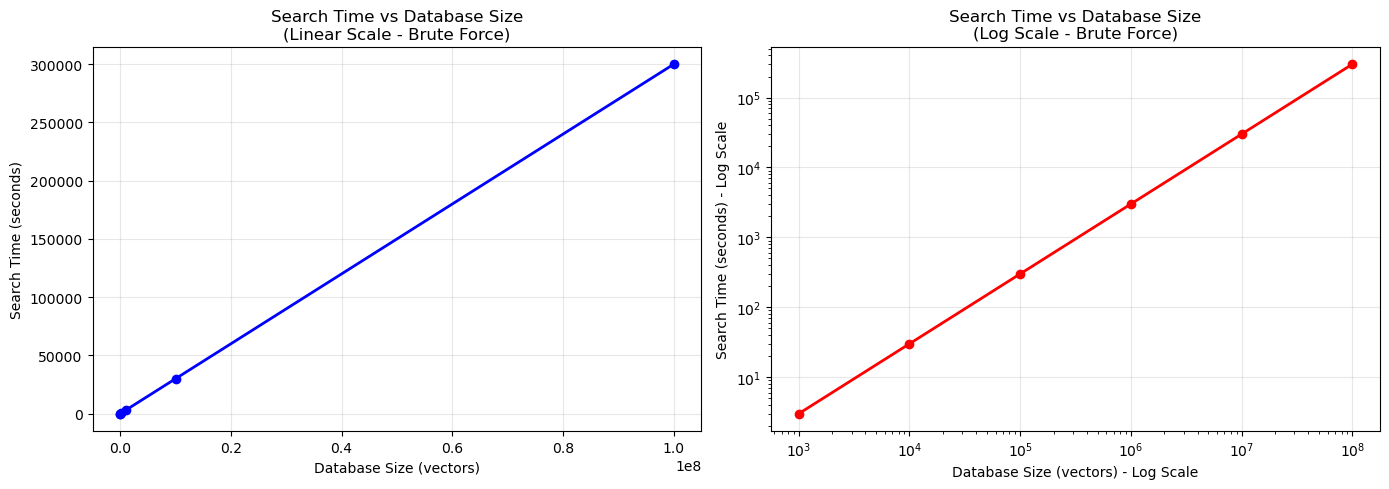


📈 As you can see, brute force becomes impractical for large datasets!


In [41]:

#  Visualizing the Problem
import matplotlib.pyplot as plt

# Estimate search times for larger databases
sizes_extended = [1000, 10000, 100000, 1000000, 10000000, 100000000]
estimated_times = [s * 0.003 for s in sizes_extended]  # Rough estimate from above

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(sizes_extended, estimated_times, 'b-o', linewidth=2)
ax1.set_xlabel('Database Size (vectors)')
ax1.set_ylabel('Search Time (seconds)')
ax1.set_title('Search Time vs Database Size\n(Linear Scale - Brute Force)')
ax1.grid(True, alpha=0.3)

# Log scale
ax2.loglog(sizes_extended, estimated_times, 'r-o', linewidth=2)
ax2.set_xlabel('Database Size (vectors) - Log Scale')
ax2.set_ylabel('Search Time (seconds) - Log Scale')
ax2.set_title('Search Time vs Database Size\n(Log Scale - Brute Force)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 As you can see, brute force becomes impractical for large datasets!")
